# Réalisez une classification supervisée d'images

Pour l'entreprise Place de marché, ma mission est de réaliser une classification supervisée à partir des images et de mettres en place une data augmentation afin d’optimiser le modèle.

## Import des librairies 

In [1]:
import openfoodfacts
import pandas as pd
import sys
import re

## Collectes des produits à base de champagne

In [3]:
print("--- MISSION : COLLECTE DES PRODUITS À BASE DE CHAMPAGNE ---")

# 1. Configuration
my_user_agent = "ProjetMarketplace - Etudiant Data Scientist"
api = openfoodfacts.API(user_agent=my_user_agent)

search_term = "champagne"
page_size = 100  # On scanne large pour filtrer ensuite

# 2. Définition des Motifs d'Exclusion (Règles NLP)
# Ces motifs identifient quand "Champagne" désigne la RÉGION et non l'ingrédient.
BAD_PATTERNS = [
    r"de la\s+champagne",      # Ex: "Miel de la Champagne" (Origine)
    r"en\s+champagne",         # Ex: "Fabriqué en Champagne" (Lieu)
    r"champagne\s+ardenne",    # Ex: "Région Champagne Ardenne"
    r"champagne\s+vigny"       # Ex: Lieux-dits spécifiques
]

try:
    # 3. Collecte via l'API
    print(f"1. Recherche API de {page_size} produits contenant '{search_term}'...")
    results = api.product.text_search(search_term, page_size=page_size)
    products = results.get('products', [])
    
    extracted_data = []
    
    if not products:
        print("Aucun produit trouvé.")
    else:
        print(f"2. Filtrage sémantique en cours sur {len(products)} candidats...")
        
        for p in products:
            # Récupération et nettoyage
            ingredients = p.get('ingredients_text', '')
            if not ingredients: continue # On saute si pas d'ingrédients
            
            ingredients_lower = str(ingredients).lower().strip()
            
            # --- FILTRE 1 : Le mot existe-t-il ? ---
            # \b assure qu'on ne prend pas "champignons"
            has_word = re.search(r'\bchampagne\b', ingredients_lower)
            
            # --- FILTRE 2 : Est-ce un contexte géographique ? ---
            is_geographic = False
            for pattern in BAD_PATTERNS:
                if re.search(pattern, ingredients_lower):
                    is_geographic = True
                    break
            
            # --- DÉCISION ---
            # On garde uniquement si le mot est là ET ce n'est pas la région
            if has_word and not is_geographic:
                
                extracted_data.append({
                    'foodId': p.get('code', 'N/A'),
                    'label': p.get('product_name', 'N/A'),
                    'category': p.get('categories', 'N/A'),
                    'foodContentsLabel': ingredients[:100] + "...", # On coupe pour l'affichage
                    'image': p.get('image_url', 'N/A')
                })

            # On s'arrête à 10 produits validés
            if len(extracted_data) >= 10:
                break
        
    # 4. Export
    if not extracted_data:
        print("Aucun produit valide trouvé après filtrage.")
    else:
        df_champagne = pd.DataFrame(extracted_data)
        output_filename = 'champagne_ingredient_final.csv' 
        df_champagne.to_csv(output_filename, index=False, encoding='utf-8')
        
        print(f"\n--- SUCCÈS ---")
        print(f"{len(df_champagne)} produits 'à base de champagne' validés et sauvegardés.")
        
        # Affichage propre pour le notebook
        pd.set_option('display.max_colwidth', None) # Voir tout le texte
        print("\nAperçu des résultats :")
        print(df_champagne[['label', 'foodContentsLabel']])

except Exception as e:
    print(f"Erreur critique : {e}", file=sys.stderr)

--- MISSION : COLLECTE DES PRODUITS À BASE DE CHAMPAGNE ---
1. Recherche API de 100 produits contenant 'champagne'...
2. Filtrage sémantique en cours sur 100 candidats...

--- SUCCÈS ---
10 produits 'à base de champagne' validés et sauvegardés.

Aperçu des résultats :
                                                           label  \
0                                  Rillettes de homard au cognac   
1                                                                  
2                        Veuve Clicquot Champagne Ponsardin Brut   
3                                             Nicolas Feuillatte   
4                        Champagne Alfred Rothschild et Cie brut   
5                               Edle Trüffel - Marc de Champagne   
6                                              Champagne Ruinart   
7  Tripes mijotées à l'Ancienne et cuisinées à la fine champagne   
8                                            Champagne AOP, brut   
9                                          champagn

In [5]:
df_champagne

,foodId,label,category,foodContentsLabel,image
0,4056489843696,Rillettes de homard au cognac,"Seafood, Fishes and their products, Fish preparations, fr:Rillettes de homard au cognac et champagne, en:lobster-rillettes","Chair de homard américain 49%, huile de colza, colin d'Alaska, eau, double concentré de tomates, Cha...",https://images.openfoodfacts.org/images/products/405/648/984/3696/front_fr.3.400.jpg
1,3258431220000,,"Boissons, Boissons alcoolisées, Vins, Vins effervescents, Champagnes, Champagnes bruts",Champagne...,https://images.openfoodfacts.org/images/products/325/843/122/0000/front_en.4.400.jpg
2,3049610004104,Veuve Clicquot Champagne Ponsardin Brut,"Boissons et préparations de boissons, Boissons, Boissons alcoolisées, Vins, Vins effervescents, Champagnes",Champagne...,https://images.openfoodfacts.org/images/products/304/961/000/4104/front_fr.39.400.jpg
3,3282946015837,Nicolas Feuillatte,"Boissons, Boissons alcoolisées, Vins, Vins français, Vins effervescents, Champagnes, Champagnes français, Champagnes bruts","Champagne, Contient des _sulfites_...",https://images.openfoodfacts.org/images/products/328/294/601/5837/front_fr.7.400.jpg
4,3113910312013,Champagne Alfred Rothschild et Cie brut,"Boissons, Boissons alcoolisées, Vins, Vins français, Vins effervescents, Champagnes, Champagnes français, Champagnes bruts",Champagne brut (contient _sulfites_)...,https://images.openfoodfacts.org/images/products/311/391/031/2013/front_fr.3.400.jpg
5,4061463055538,Edle Trüffel - Marc de Champagne,"Imbiss, Süßer Snack, Kakao und Kakaoprodukte, Süßwaren, Schokoladenkonfekt, Pralinen, Schokoladetrüffel","Zucker, Kakaomasse, Kakaobutter, Marc de Champagne (5,5%), Butter, Feuchthaltemittel (Sorbit), Gluko...",https://images.openfoodfacts.org/images/products/406/146/305/5538/front_de.26.400.jpg
6,3185370283905,Champagne Ruinart,"Boissons, Boissons alcoolisées, Vins, Vins effervescents, Champagnes",champagne...,https://images.openfoodfacts.org/images/products/318/537/028/3905/front_en.5.400.jpg
7,3270271513050,Tripes mijotées à l'Ancienne et cuisinées à la fine champagne,"Plats-cuisinees,Plats préparés,Tripes","estomacs de boœuf (origine France), eau, oignons, carottes, sel, gélatine, extraits d'épices, Cognac...",https://images.openfoodfacts.org/images/products/327/027/151/3050/front_fr.30.400.jpg
8,3416181017169,"Champagne AOP, brut","Boissons, Boissons alcoolisées, Vins, Vins effervescents, Champagnes, Champagnes bruts",Champagne...,https://images.openfoodfacts.org/images/products/341/618/101/7169/front_fr.7.400.jpg
9,0070200631151,champagne vinaigrette,"Condiments, Sauces, Salad dressings, Groceries","Canola and soybean oil, white wine (contains sulfites), water, vinegars (champagne and white wine), ...",https://images.openfoodfacts.org/images/products/007/020/063/1151/front_en.15.400.jpg


## Classification supervisé d'images via CNN transfer learning

### Le jeu de données

In [3]:
df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")
df

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,2015-12-01 10:15:43 +0000,http://www.flipkart.com/oren-empower-extra-lar...,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE88ZGTX65GH4V,1399.0,999.0,958f54f4c46b53c8a0a9b8167d9140bc.jpg,False,Oren Empower Extra Large Self Adhesive Sticker...,No rating available,No rating available,Oren Empower,"{""product_specification""=>[{""key""=>""Number of ..."
1046,fd6cbcc22efb6b761bd564c28928483c,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-large-vinyl...,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZD5GDCVQ,4930.0,1896.0,fd6cbcc22efb6b761bd564c28928483c.jpg,False,Wallmantra Large Vinyl Sticker Sticker (Pack o...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1047,5912e037d12774bb73a2048f35a00009,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-extra-large-p...,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE5UVGW2JWVWCT,4500.0,1449.0,5912e037d12774bb73a2048f35a00009.jpg,False,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,No rating available,No rating available,Uberlyfe,"{""product_specification""=>[{""key""=>""Number of ..."
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-medium-viny...,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >.

### Extraction catégorie

In [6]:
# Extrayons la catégorie principale (le premier niveau)
# Ex: ["Home Furnishing >> Curtains..."] -> "Home Furnishing"
def extract_main_category(tree_str):
    try:
        # Enlève les crochets et guillemets, puis prend le premier élément
        main_cat = tree_str.strip('[]"').split('>>')[0].strip()
        return main_cat
    except Exception:
        return 'Unknown' # Gérer les cas où le format est mauvais

df['main_category'] = df['product_category_tree'].apply(extract_main_category)

# Vous pouvez maintenant vérifier vos catégories
print("Distribution des catégories principales :")
print(df['main_category'].value_counts())

Distribution des catégories principales :
main_category
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150
Name: count, dtype: int64


### Classification supervisé

--- Début de la Classification Supervisée ---
Étape 1/6 : Préparation des données...
Trouvé 7 classes uniques.
Taille du set d'entraînement : 840 images
Taille du set de validation : 210 images
Étape 3/6 : Création des générateurs (Data Augmentation)...
Found 840 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.
Étape 4/6 : Construction du modèle VGG16...


2025-11-12 16:12:44.080922: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-11-12 16:12:44.080996: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-12 16:12:44.081005: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-12 16:12:44.081036: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-12 16:12:44.081064: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

...

 3/26 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - accuracy: 0.1701 - loss: 14.8931

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 404ms/step - accuracy: 0.4121 - loss: 8.5445 - val_accuracy: 0.7031 - val_loss: 3.6443
Epoch 2/15
 1/26 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.5312 - loss: 4.9860

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5312 - loss: 4.9860 - val_accuracy: 0.7344 - val_loss: 3.5649
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 356ms/step - accuracy: 0.6658 - loss: 4.5717 - val_accuracy: 0.7604 - val_loss: 3.6492
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7500 - loss: 2.6856 - val_accuracy: 0.7500 - val_loss: 3.6895
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 349ms/step - accuracy: 0.7153 - loss: 4.4490 - val_accuracy: 0.7604 - val_loss: 3.3566
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6562 - loss: 4.5102 - val_accuracy: 0.7656 - val_loss: 3.3892
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 379ms/step - accuracy: 0.7376 - loss: 3.2732 - val_accuracy: 0.7812 - val_loss: 3.4258
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7188 - loss: 3.6088 - val_accuracy: 0.7917 - val_loss: 3.4548
Epoch 9/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step - accuracy: 0.7463 - loss: 3.4400 - val_accuracy: 0.7552 - val_lo

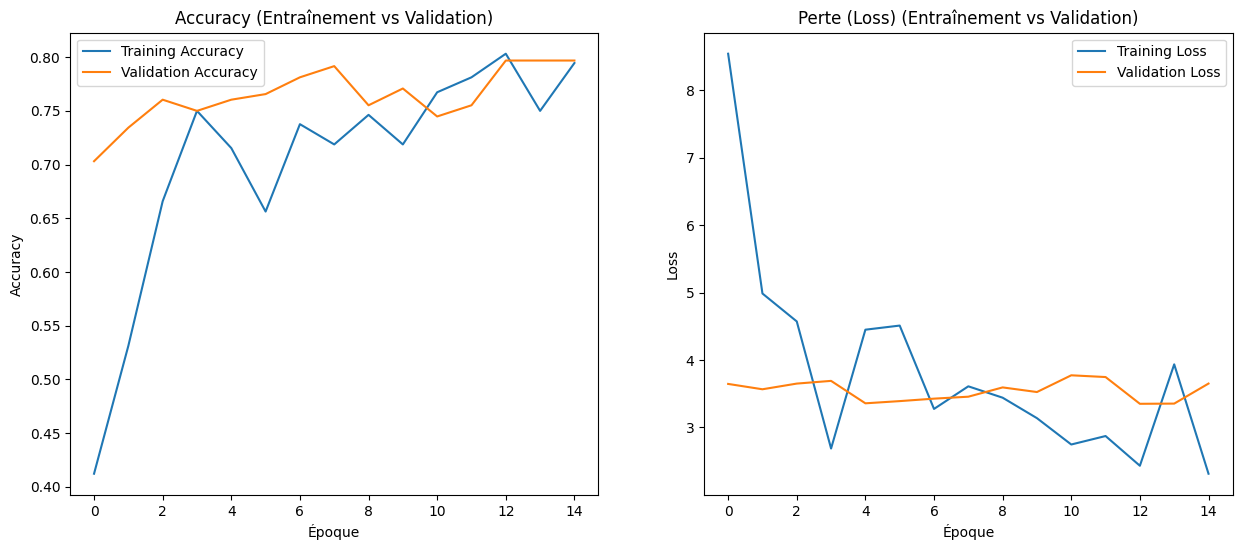

Calcul de la Matrice de Confusion et du Rapport...
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step

--- Rapport de Classification ---
                            precision    recall  f1-score   support

                 Baby Care       0.84      0.53      0.65        30
  Beauty and Personal Care       1.00      0.70      0.82        30
                 Computers       0.81      0.70      0.75        30
Home Decor & Festive Needs       0.65      0.87      0.74        30
           Home Furnishing       0.68      0.90      0.77        30
          Kitchen & Dining       0.78      0.93      0.85        30
                   Watches       0.93      0.87      0.90        30

                  accuracy                           0.79       210
                 macro avg       0.81      0.79      0.78       210
              weighted avg       0.81      0.79      0.78       210


--- Matrice de Confusion ---


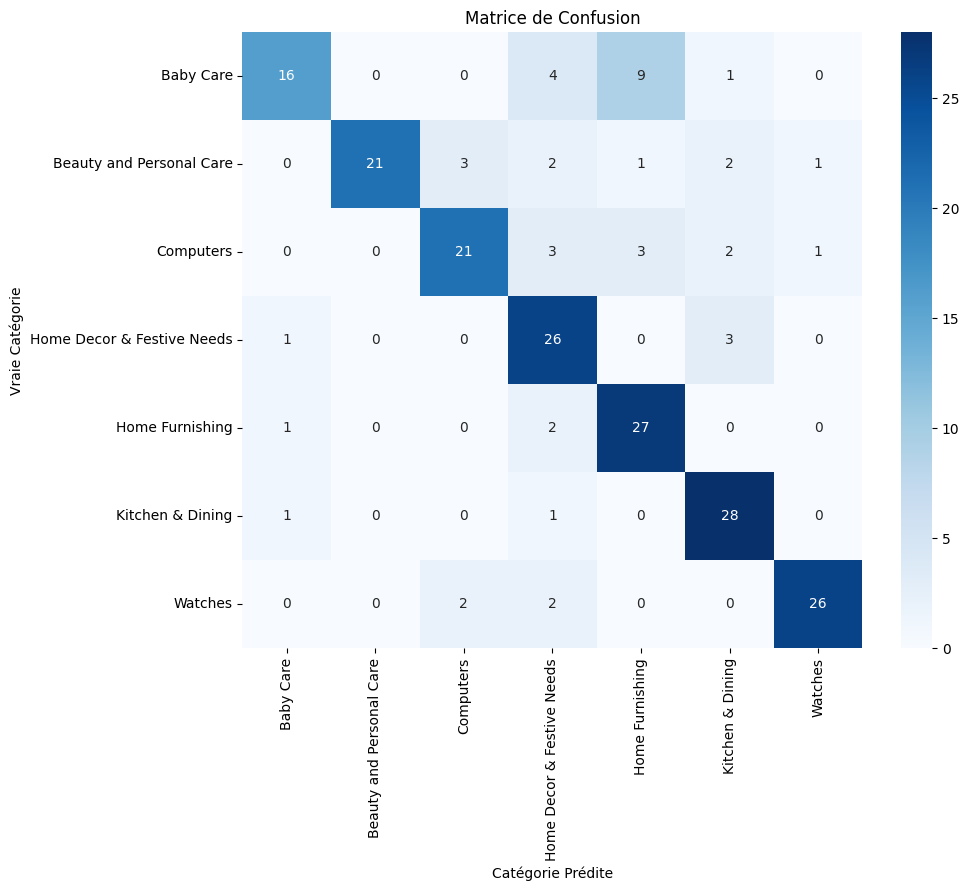

--- FIN DE LA CLASSIFICATION ---


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

print("--- Début de la Classification Supervisée ---")

# ======================================================
# ÉTAPE 0 : DÉFINIR LES PARAMÈTRES
# ======================================================
IMG_SIZE = 224    # VGG16 attend du 224x224
BATCH_SIZE = 32   # Taille des lots
EPOCHS = 15       # Nombre d'époques d'entraînement (10-15 est un bon début)

# ======================================================
# ÉTAPE 1 : PRÉPARATION DES DONNÉES (DataFrame)
# ======================================================
print("Étape 1/6 : Préparation des données...")

# S'assurer que le chemin est là
image_folder_path = '/Users/mathiasfidol/Openclassroom projet 6/'
if 'image_path' not in df.columns:
    df['image_path'] = image_folder_path + df['image']

# S'assurer que les catégories sont propres (au cas où)
df['main_category'] = df['main_category'].astype(str)
NUM_CLASSES = df['main_category'].nunique()

print(f"Trouvé {NUM_CLASSES} classes uniques.")

# ======================================================
# ÉTAPE 2 : DIVISION TRAIN / VALIDATION
# ======================================================
# On divise le DataFrame, pas les images elles-mêmes
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, # 20% pour la validation
    random_state=42,
    stratify=df['main_category'] # Assure qu'on a toutes les catégories
)
print(f"Taille du set d'entraînement : {len(train_df)} images")
print(f"Taille du set de validation : {len(val_df)} images")

# ======================================================
# ÉTAPE 3 : DATA AUGMENTATION (Générateurs)
# ======================================================
print("Étape 3/6 : Création des générateurs (Data Augmentation)...")

# Générateur pour l'entraînement (AVEC augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Normalisation VGG16
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Générateur pour la validation (SANS augmentation, juste normalisation)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Créer les "flows" (flux) depuis le DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',         # Colonne avec les chemins
    y_col='main_category',      # Colonne avec les labels
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'    # Important car on a > 2 classes
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='main_category',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Pas besoin de mélanger la validation
)

# ======================================================
# ÉTAPE 4 : CONSTRUCTION DU MODÈLE (TRANSFER LEARNING)
# ======================================================
print("Étape 4/6 : Construction du modèle VGG16...")

# 1. Charger le modèle de base (VGG16) sans la tête de classification
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Geler les poids du modèle de base
base_model.trainable = False

# 3. Ajouter notre propre tête de classification
x = base_model.output
x = GlobalAveragePooling2D()(x) # Aplatit les features
x = Dense(256, activation='relu')(x) # Une couche dense
x = Dropout(0.5)(x) # Pour éviter l'overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Couche finale

# 4. Créer le modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compiler le modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Standard pour multi-classe
    metrics=['accuracy']
)

model.summary()

# ======================================================
# ÉTAPE 5 : ENTRAÎNEMENT DU MODÈLE
# ======================================================
print("Étape 5/6 : Démarrage de l'entraînement...")

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // BATCH_SIZE, # (840 / 32)
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=len(val_df) // BATCH_SIZE # (210 / 32)
)

print("Entraînement terminé.")

# ======================================================
# ÉTAPE 6 : ÉVALUATION
# ======================================================
print("Étape 6/6 : Évaluation du modèle...")

# 6.1 Graphique des performances (Accuracy/Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique de l'Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy (Entraînement vs Validation)')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Graphique de la Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Perte (Loss) (Entraînement vs Validation)')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Loss')
ax2.legend()
plt.show()

# 6.2 Matrice de Confusion et Rapport
print("Calcul de la Matrice de Confusion et du Rapport...")

# Obtenir les prédictions sur le set de validation
# On réinitialise le générateur pour être sûr
val_generator.reset()
y_pred_probs = model.predict(
    val_generator, 
    steps=(len(val_df) // BATCH_SIZE) + 1 # Assurer qu'on couvre tout
)

# On ne garde que les prédictions pour le nombre exact d'images
y_pred_probs = y_pred_probs[:len(val_df)]

# Convertir les probabilités (softmax) en classe unique
y_pred = np.argmax(y_pred_probs, axis=1)

# Obtenir les vraies classes
y_true = val_generator.classes

# Obtenir les noms des classes (labels)
class_names = list(val_generator.class_indices.keys())

# Rapport de Classification
print("\n--- Rapport de Classification ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matrice de Confusion
print("\n--- Matrice de Confusion ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie Catégorie')
plt.xlabel('Catégorie Prédite')
plt.show()

print("--- FIN DE LA CLASSIFICATION ---")